In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded OK")

Libraries loaded OK


In [5]:
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

df = pd.read_csv(url, header=None, names=columns)
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Dataset shape: (125973, 43)

Label distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [7]:
df.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [ ]:
# Separar features numéricas y convertir label a binario
df['is_attack'] = (df['label'] != 'normal').astype(int)

print(f"Normal: {(df['is_attack']==0).sum()}")
print(f"Attacks: {(df['is_attack']==1).sum()}")
print(f"Attack rate: {df['is_attack'].mean():.2%}")

#Dejamos el dataset sin estas columnas pq son la prediccion, es contra lo que vamos a evaluar nuestra prediccion
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['is_attack', 'difficulty']]

print(f"\nFeatures seleccionadas: {len(numeric_features)}")

Normal: 67343
Attacks: 58630
Attack rate: 46.54%

Features seleccionadas: 38


In [9]:
print(numeric_features)

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


# Escalar features (importante para LOF e Isolation Forest)
X = df[numeric_features].fillna(0)
y = df['is_attack']

#`StandardScaler` transforma cada feature para que tenga **media = 0 y desvío estándar = 1**. Después del scaling todas las features están en la misma escala y el modelo las trata igual.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Trabajar con una muestra de 20K para que corra rápido
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 20000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y.iloc[sample_idx]

print(f"Sample shape: {X_sample.shape}")
print(f"Attack rate en sample: {y_sample.mean():.2%}")

In [11]:
from sklearn.model_selection import train_test_split

# Stratified sampling — mantiene proporción de cada clase
_, df_sample = train_test_split(
    df,
    test_size=20000/len(df),
    stratify=df['label'],
    random_state=42
)

# Escalar features
X = df[numeric_features].fillna(0)
scaler = StandardScaler()
scaler.fit(X)  # fit sobre el dataset completo

X_sample = scaler.transform(df_sample[numeric_features].fillna(0))
y_sample = df_sample['is_attack']

# Verificar que la distribución se preservó
print("Distribución original vs sample:")
comparison = pd.DataFrame({
    'original_%': df['label'].value_counts(normalize=True).mul(100).round(2),
    'sample_%': df_sample['label'].value_counts(normalize=True).mul(100).round(2)
})
print(comparison.head(10))

print(f"\nSample shape: {X_sample.shape}")
print(f"Attack rate en sample: {y_sample.mean():.2%}")

Distribución original vs sample:
                 original_%  sample_%
label                                
back                   0.76      0.76
buffer_overflow        0.02      0.02
ftp_write              0.01      0.00
guess_passwd           0.04      0.04
imap                   0.01      0.01
ipsweep                2.86      2.86
land                   0.01      0.02
loadmodule             0.01      0.00
multihop               0.01      0.00
neptune               32.72     32.71

Sample shape: (20000, 38)
Attack rate en sample: 46.54%


In [13]:
print("Entrenando Isolation Forest...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.4654,  # usamos el attack rate real del sample
    random_state=42,
    n_jobs=-1
)

iso_pred = iso_forest.fit_predict(X_sample)
iso_pred_binary = (iso_pred == -1).astype(int)

print("\nResultados Isolation Forest:")
print(classification_report(y_sample, iso_pred_binary,
                           target_names=['Normal', 'Attack']))

Entrenando Isolation Forest...



Resultados Isolation Forest:
              precision    recall  f1-score   support

      Normal       0.67      0.67      0.67     10692
      Attack       0.63      0.63      0.63      9308

    accuracy                           0.65     20000
   macro avg       0.65      0.65      0.65     20000
weighted avg       0.65      0.65      0.65     20000



In [14]:
print("Entrenando LOF (puede tardar 1-2 minutos)...")

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.4654,
    n_jobs=-1
)

lof_pred = lof.fit_predict(X_sample)
lof_pred_binary = (lof_pred == -1).astype(int)

print("\nResultados LOF:")
print(classification_report(y_sample, lof_pred_binary,
                           target_names=['Normal', 'Attack']))

Entrenando LOF (puede tardar 1-2 minutos)...

Resultados LOF:
              precision    recall  f1-score   support

      Normal       0.51      0.51      0.51     10692
      Attack       0.44      0.44      0.44      9308

    accuracy                           0.48     20000
   macro avg       0.48      0.48      0.48     20000
weighted avg       0.48      0.48      0.48     20000



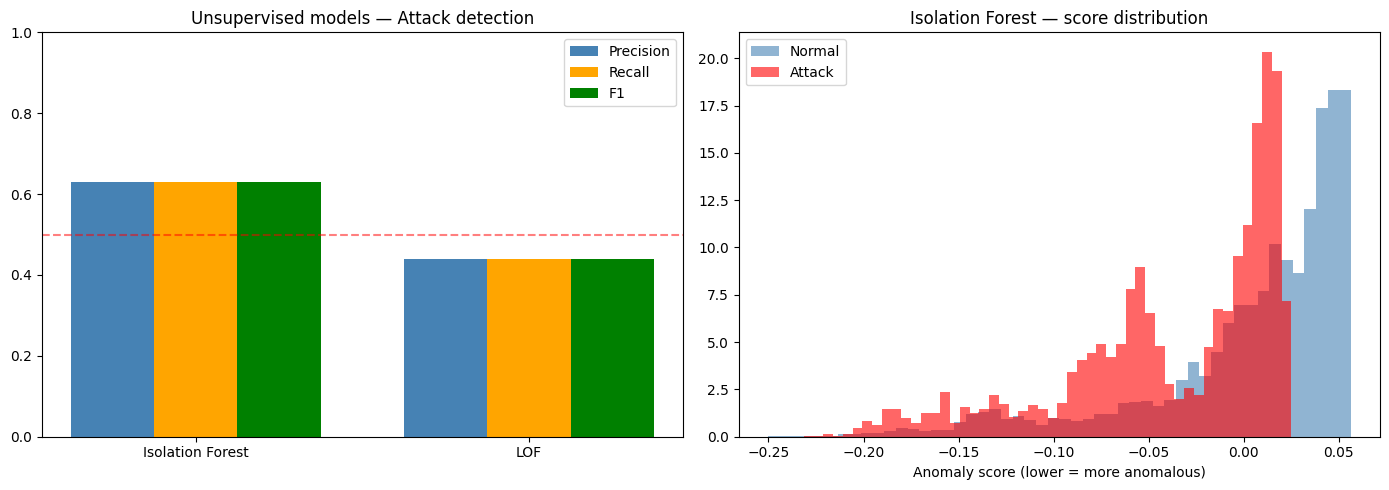

Gráfico guardado.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparación de resultados
models = ['Isolation Forest', 'LOF']
precisions = [0.63, 0.44]
recalls = [0.63, 0.44]
f1s = [0.63, 0.44]

x = np.arange(len(models))
width = 0.25

axes[0].bar(x - width, precisions, width, label='Precision', color='steelblue')
axes[0].bar(x, recalls, width, label='Recall', color='orange')
axes[0].bar(x + width, f1s, width, label='F1', color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1)
axes[0].set_title('Unsupervised models — Attack detection')
axes[0].legend()
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')

# Distribución de anomaly scores — Isolation Forest
iso_scores = iso_forest.decision_function(X_sample)
axes[1].hist(iso_scores[y_sample==0], bins=50, alpha=0.6,
             color='steelblue', label='Normal', density=True)
axes[1].hist(iso_scores[y_sample==1], bins=50, alpha=0.6,
             color='red', label='Attack', density=True)
axes[1].set_title('Isolation Forest — score distribution')
axes[1].set_xlabel('Anomaly score (lower = more anomalous)')
axes[1].legend()

plt.tight_layout()
plt.savefig('unsupervised_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado.")